# Notebook 04 — Optimisation des hyperparamètres SWRO

**PFE — Master Science des Données**

## Objectif

Améliorer les modèles obtenus dans le Notebook 03 en optimisant leurs hyperparamètres.

Les deux modèles retenus pour l'optimisation sont :

- **MLP Regressor**
- **Gradient Boosting Regressor**

Le meilleur modèle final sera sélectionné uniquement à partir des performances de validation croisée. Le jeu de test reste indépendant jusqu'à l'évaluation finale.

In [1]:
# ============================================================
# 0. IMPORTS ET CONFIGURATION
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import time

from pathlib import Path

from sklearn.model_selection import RandomizedSearchCV, KFold
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

RANDOM_STATE = 42

DATA_DIR = Path("data/preprocessed")
MODEL_DIR = Path("models")
RESULT_DIR = Path("results")

MODEL_DIR.mkdir(parents=True, exist_ok=True)
RESULT_DIR.mkdir(parents=True, exist_ok=True)

print("Configuration chargée.")

Configuration chargée.


## 1. Chargement des données

On recharge les mêmes données préparées dans le Notebook 02 afin de conserver exactement le même protocole expérimental.

In [2]:
X_train = pd.read_csv(DATA_DIR / "X_train_scaled.csv")
X_val = pd.read_csv(DATA_DIR / "X_val_scaled.csv")
X_test = pd.read_csv(DATA_DIR / "X_test_scaled.csv")

y_train = pd.read_csv(DATA_DIR / "y_train.csv").squeeze("columns")
y_val = pd.read_csv(DATA_DIR / "y_val.csv").squeeze("columns")
y_test = pd.read_csv(DATA_DIR / "y_test.csv").squeeze("columns")

X_train_full = pd.concat([X_train, X_val], ignore_index=True)
y_train_full = pd.concat([y_train, y_val], ignore_index=True)

print("Train :", X_train.shape)
print("Validation :", X_val.shape)
print("Test :", X_test.shape)
print("Train + Validation :", X_train_full.shape)

Train : (7000, 8)
Validation : (1500, 8)
Test : (1500, 8)
Train + Validation : (8500, 8)


## 2. Protocole expérimental

Pour éviter d'utiliser le test pendant l'optimisation :

```text
Train + Validation
        ↓
Validation croisée 5-fold
        ↓
Recherche des hyperparamètres
        ↓
Meilleur MLP / meilleur Gradient Boosting
        ↓
Réentraînement sur Train + Validation
        ↓
Test final UNE SEULE FOIS
```

Le test n'intervient donc pas dans la sélection des hyperparamètres.

## 3. Fonction d'évaluation

In [3]:
def evaluate_regression(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2

## 4. Validation croisée

Nous utilisons une validation croisée 5-fold avec mélange aléatoire reproductible.

In [4]:
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

print(cv)

KFold(n_splits=5, random_state=42, shuffle=True)


# Partie A — Optimisation du MLP

Le MLP est le meilleur modèle du Notebook 03 sur le test selon le protocole précédent. Nous explorons maintenant plusieurs architectures et paramètres d'entraînement.

In [5]:
mlp = MLPRegressor(
    max_iter=1500,
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=30,
    random_state=RANDOM_STATE
)

mlp_param_distributions = {
    "hidden_layer_sizes": [
        (32,),
        (64,),
        (128,),
        (64, 32),
        (128, 64),
        (128, 64, 32)
    ],
    "activation": ["relu", "tanh"],
    "alpha": [1e-5, 1e-4, 1e-3, 1e-2],
    "learning_rate_init": [1e-4, 5e-4, 1e-3, 5e-3],
    "batch_size": [32, 64, 128]
}

mlp_search = RandomizedSearchCV(
    estimator=mlp,
    param_distributions=mlp_param_distributions,
    n_iter=25,
    scoring="neg_root_mean_squared_error",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

start = time.perf_counter()
mlp_search.fit(X_train_full, y_train_full)
mlp_time = time.perf_counter() - start

print(f"Temps d'optimisation MLP : {mlp_time:.2f} s")
print("Meilleurs paramètres MLP :")
print(mlp_search.best_params_)
print(f"Meilleur RMSE CV MLP : {-mlp_search.best_score_:.6f}")

Fitting 5 folds for each of 25 candidates, totalling 125 fits
Temps d'optimisation MLP : 107.66 s
Meilleurs paramètres MLP :
{'learning_rate_init': 0.0001, 'hidden_layer_sizes': (128, 64, 32), 'batch_size': 128, 'alpha': 1e-05, 'activation': 'tanh'}
Meilleur RMSE CV MLP : 0.110159


## 5. Analyse des essais MLP

In [6]:
mlp_cv_results = pd.DataFrame(mlp_search.cv_results_)

mlp_results_table = (
    mlp_cv_results[
        [
            "rank_test_score",
            "mean_test_score",
            "std_test_score",
            "mean_train_score",
            "params"
        ]
    ]
    .sort_values("rank_test_score")
    .copy()
)

mlp_results_table["CV_RMSE"] = -mlp_results_table["mean_test_score"]
mlp_results_table["CV_RMSE_STD"] = mlp_results_table["std_test_score"]

display(
    mlp_results_table.head(10)[
        ["rank_test_score", "CV_RMSE", "CV_RMSE_STD", "params"]
    ]
)

,rank_test_score,CV_RMSE,CV_RMSE_STD,params
13,1,0.110159,0.001087,"{'learning_rate_init': 0.0001, 'hidden_layer_s..."
5,2,0.110162,0.000830,"{'learning_rate_init': 0.0001, 'hidden_layer_s..."
18,3,0.110241,0.000852,"{'learning_rate_init': 0.0001, 'hidden_layer_s..."
9,4,0.110290,0.000831,"{'learning_rate_init': 0.0001, 'hidden_layer_s..."
10,5,0.110416,0.001126,"{'learning_rate_init': 0.001, 'hidden_layer_si..."
20,6,0.110485,0.001202,"{'learning_rate_init': 0.0005, 'hidden_layer_s..."
14,7,0.110640,0.000729,"{'learning_rate_init': 0.001, 'hidden_layer_si..."
22,8,0.110775,0.000727,"{'learning_rate_init': 0.0005, 'hidden_layer_s..."
3,9,0.111001,0.001225,"{'learning_rate_init': 0.001, 'hidden_layer_si..."
4,10,0.111153,0.000949,"{'learning_rate_init': 0.001, 'hidden_layer_si..."


# Partie B — Optimisation du Gradient Boosting

In [7]:
gbr = GradientBoostingRegressor(
    random_state=RANDOM_STATE
)

gbr_param_distributions = {
    "n_estimators": [100, 150, 200, 300, 400],
    "learning_rate": [0.01, 0.03, 0.05, 0.08, 0.1],
    "max_depth": [2, 3, 4, 5],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 4, 8],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "max_features": [None, "sqrt", "log2"]
}

gbr_search = RandomizedSearchCV(
    estimator=gbr,
    param_distributions=gbr_param_distributions,
    n_iter=30,
    scoring="neg_root_mean_squared_error",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

start = time.perf_counter()
gbr_search.fit(X_train_full, y_train_full)
gbr_time = time.perf_counter() - start

print(f"Temps d'optimisation Gradient Boosting : {gbr_time:.2f} s")
print("Meilleurs paramètres Gradient Boosting :")
print(gbr_search.best_params_)
print(f"Meilleur RMSE CV Gradient Boosting : {-gbr_search.best_score_:.6f}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Temps d'optimisation Gradient Boosting : 29.99 s
Meilleurs paramètres Gradient Boosting :
{'subsample': 0.7, 'n_estimators': 400, 'min_samples_split': 20, 'min_samples_leaf': 8, 'max_features': 'sqrt', 'max_depth': 4, 'learning_rate': 0.03}
Meilleur RMSE CV Gradient Boosting : 0.113597


## 6. Analyse des essais Gradient Boosting

In [8]:
gbr_cv_results = pd.DataFrame(gbr_search.cv_results_)

gbr_results_table = (
    gbr_cv_results[
        [
            "rank_test_score",
            "mean_test_score",
            "std_test_score",
            "mean_train_score",
            "params"
        ]
    ]
    .sort_values("rank_test_score")
    .copy()
)

gbr_results_table["CV_RMSE"] = -gbr_results_table["mean_test_score"]
gbr_results_table["CV_RMSE_STD"] = gbr_results_table["std_test_score"]

display(
    gbr_results_table.head(10)[
        ["rank_test_score", "CV_RMSE", "CV_RMSE_STD", "params"]
    ]
)

,rank_test_score,CV_RMSE,CV_RMSE_STD,params
19,1,0.113597,0.001229,"{'subsample': 0.7, 'n_estimators': 400, 'min_s..."
4,2,0.114781,0.000941,"{'subsample': 0.7, 'n_estimators': 150, 'min_s..."
18,3,0.115591,0.001163,"{'subsample': 0.7, 'n_estimators': 200, 'min_s..."
20,4,0.115775,0.001533,"{'subsample': 0.9, 'n_estimators': 150, 'min_s..."
8,5,0.115892,0.001000,"{'subsample': 1.0, 'n_estimators': 100, 'min_s..."
22,6,0.117304,0.000795,"{'subsample': 1.0, 'n_estimators': 200, 'min_s..."
6,7,0.117696,0.001786,"{'subsample': 0.9, 'n_estimators': 200, 'min_s..."
0,8,0.117936,0.001320,"{'subsample': 1.0, 'n_estimators': 300, 'min_s..."
21,9,0.118079,0.000947,"{'subsample': 0.9, 'n_estimators': 100, 'min_s..."
9,10,0.118403,0.001931,"{'subsample': 1.0, 'n_estimators': 100, 'min_s..."


# 7. Comparaison des meilleurs modèles optimisés

,Model,CV_RMSE,CV_RMSE_STD,Search_Time_s
0,Optimized MLP,0.110159,0.001087,107.657644
1,Optimized Gradient Boosting,0.113597,0.001229,29.991913


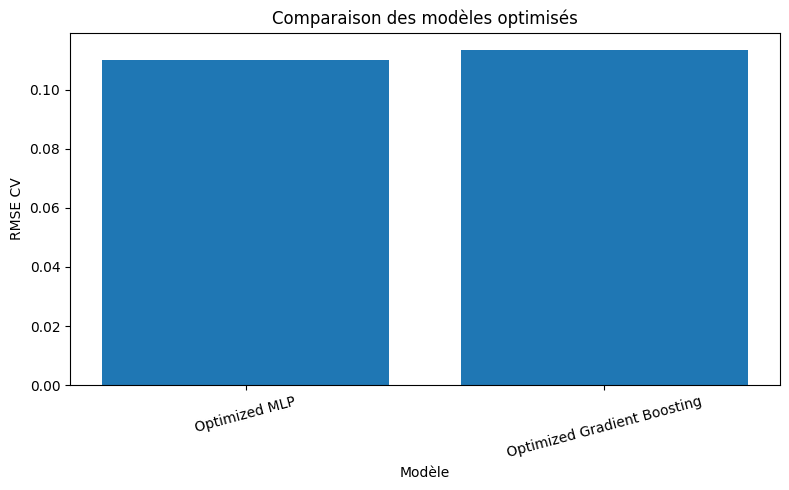

In [9]:
optimization_summary = pd.DataFrame([
    {
        "Model": "Optimized MLP",
        "CV_RMSE": -mlp_search.best_score_,
        "CV_RMSE_STD": mlp_cv_results.loc[
            mlp_search.best_index_, "std_test_score"
        ],
        "Search_Time_s": mlp_time
    },
    {
        "Model": "Optimized Gradient Boosting",
        "CV_RMSE": -gbr_search.best_score_,
        "CV_RMSE_STD": gbr_cv_results.loc[
            gbr_search.best_index_, "std_test_score"
        ],
        "Search_Time_s": gbr_time
    }
]).sort_values("CV_RMSE")

display(optimization_summary)

plt.figure(figsize=(8, 5))
plt.bar(
    optimization_summary["Model"],
    optimization_summary["CV_RMSE"]
)
plt.ylabel("RMSE CV")
plt.xlabel("Modèle")
plt.title("Comparaison des modèles optimisés")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# 8. Sélection du modèle optimisé

Le meilleur modèle est celui qui obtient le RMSE moyen CV le plus faible.

In [10]:
# ============================================================
# 8. SÉLECTION CORRECTE DU MODÈLE OPTIMISÉ
# ============================================================
# RandomizedSearchCV utilise un score négatif :
# neg_root_mean_squared_error = -RMSE
# Donc le score le plus élevé correspond au RMSE réel le plus faible.

mlp_rmse_cv = -mlp_search.best_score_
gbr_rmse_cv = -gbr_search.best_score_

model_selection = pd.DataFrame([
    {
        "Model": "Optimized MLP",
        "CV_RMSE": mlp_rmse_cv,
        "CV_RMSE_STD": mlp_cv_results.loc[
            mlp_search.best_index_, "std_test_score"
        ]
    },
    {
        "Model": "Optimized Gradient Boosting",
        "CV_RMSE": gbr_rmse_cv,
        "CV_RMSE_STD": gbr_cv_results.loc[
            gbr_search.best_index_, "std_test_score"
        ]
    }
]).sort_values("CV_RMSE").reset_index(drop=True)

display(model_selection)

if mlp_rmse_cv <= gbr_rmse_cv:
    best_search = mlp_search
    best_optimized_name = "Optimized MLP"
else:
    best_search = gbr_search
    best_optimized_name = "Optimized Gradient Boosting"

best_optimized_model = best_search.best_estimator_

print("🏆 Modèle sélectionné selon le RMSE CV :", best_optimized_name)
print(f"RMSE CV : {-best_search.best_score_:.6f} kWh/m³")
print("Hyperparamètres :")
print(best_search.best_params_)

,Model,CV_RMSE,CV_RMSE_STD
0,Optimized MLP,0.110159,0.001087
1,Optimized Gradient Boosting,0.113597,0.001229


🏆 Modèle sélectionné selon le RMSE CV : Optimized MLP
RMSE CV : 0.110159 kWh/m³
Hyperparamètres :
{'learning_rate_init': 0.0001, 'hidden_layer_sizes': (128, 64, 32), 'batch_size': 128, 'alpha': 1e-05, 'activation': 'tanh'}


# 9. Évaluation sur le test final

Le meilleur modèle optimisé a été choisi sans utiliser le test. Nous pouvons maintenant évaluer sa performance finale.

In [11]:
# ============================================================
# 9. ÉVALUATION FINALE DES DEUX MODÈLES OPTIMISÉS SUR LE TEST
# ============================================================
# Le test n'est utilisé qu'ici, après la sélection par CV.

optimized_models = {
    "Optimized MLP": mlp_search.best_estimator_,
    "Optimized Gradient Boosting": gbr_search.best_estimator_
}

final_test_results = []
test_predictions = {}

for name, model in optimized_models.items():
    predictions = model.predict(X_test)
    test_predictions[name] = predictions

    mae, rmse, r2 = evaluate_regression(y_test, predictions)

    final_test_results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

final_test_results = (
    pd.DataFrame(final_test_results)
    .sort_values("RMSE")
    .reset_index(drop=True)
)

display(final_test_results)

print("\n🏆 Meilleur modèle sur le TEST :", final_test_results.iloc[0]["Model"])
print(f"MAE  : {final_test_results.iloc[0]['MAE']:.6f} kWh/m³")
print(f"RMSE : {final_test_results.iloc[0]['RMSE']:.6f} kWh/m³")
print(f"R²   : {final_test_results.iloc[0]['R2']:.6f}")

# Le modèle final reste celui choisi par CV, pas celui choisi après avoir regardé le test.
final_model_name = best_optimized_name
final_model = best_optimized_model

y_pred_test = test_predictions[final_model_name]

print("\nModèle FINAL retenu par validation croisée :", final_model_name)

,Model,MAE,RMSE,R2
0,Optimized MLP,0.088737,0.113165,0.953030
1,Optimized Gradient Boosting,0.089905,0.114684,0.951761



🏆 Meilleur modèle sur le TEST : Optimized MLP
MAE  : 0.088737 kWh/m³
RMSE : 0.113165 kWh/m³
R²   : 0.953030

Modèle FINAL retenu par validation croisée : Optimized MLP


# 10. Comparaison Baseline vs Optimisé

Cette comparaison permet de quantifier le gain apporté par l'optimisation.

In [12]:
# ============================================================
# 10. COMPARAISON BASELINE VS MODÈLES OPTIMISÉS
# ============================================================

baseline_file = RESULT_DIR / "best_model_test_results.csv"

if baseline_file.exists():
    baseline_results = pd.read_csv(baseline_file)

    comparison = pd.concat(
        [
            baseline_results,
            final_test_results
        ],
        ignore_index=True
    )

    display(comparison)

    baseline_row = baseline_results.iloc[0]

    print("\nComparaison avec le baseline :")
    for _, row in final_test_results.iterrows():
        rmse_gain = baseline_row["RMSE"] - row["RMSE"]
        mae_gain = baseline_row["MAE"] - row["MAE"]

        print(f"\n{row['Model']}")
        print(f"  Gain RMSE : {rmse_gain:.6f} kWh/m³")
        print(f"  Gain MAE  : {mae_gain:.6f} kWh/m³")
        print(f"  ΔR²       : {row['R2'] - baseline_row['R2']:.6f}")
else:
    comparison = final_test_results.copy()
    print("Résultat baseline non trouvé.")

,Model,MAE,RMSE,R2
0,MLP,0.090223,0.114807,0.951657
1,Optimized MLP,0.088737,0.113165,0.953030
2,Optimized Gradient Boosting,0.089905,0.114684,0.951761



Comparaison avec le baseline :

Optimized MLP
  Gain RMSE : 0.001642 kWh/m³
  Gain MAE  : 0.001486 kWh/m³
  ΔR²       : 0.001373

Optimized Gradient Boosting
  Gain RMSE : 0.000124 kWh/m³
  Gain MAE  : 0.000318 kWh/m³
  ΔR²       : 0.000104


# 11. Réel vs prédit — modèle optimisé

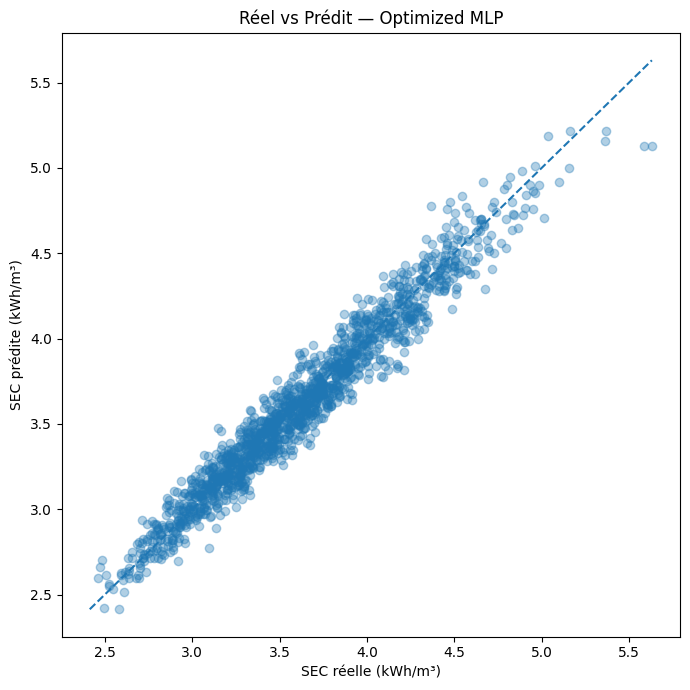

In [13]:
# ============================================================
# 11. RÉEL VS PRÉDIT — MODÈLE FINAL
# ============================================================

plt.figure(figsize=(7, 7))

plt.scatter(
    y_test,
    y_pred_test,
    alpha=0.35
)

minimum = min(y_test.min(), y_pred_test.min())
maximum = max(y_test.max(), y_pred_test.max())

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)

plt.xlabel("SEC réelle (kWh/m³)")
plt.ylabel("SEC prédite (kWh/m³)")
plt.title(f"Réel vs Prédit — {final_model_name}")
plt.tight_layout()
plt.show()

# 12. Analyse des résidus

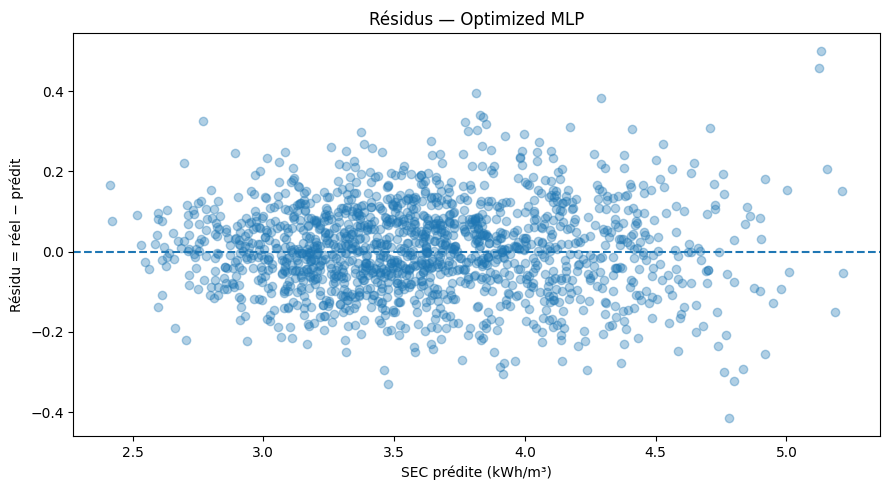

Résidu moyen : 0.006993710534393138
Écart-type : 0.1129489537664488


In [14]:
# ============================================================
# 12. ANALYSE DES RÉSIDUS — MODÈLE FINAL
# ============================================================

residuals = y_test.values - y_pred_test

plt.figure(figsize=(9, 5))
plt.scatter(y_pred_test, residuals, alpha=0.35)
plt.axhline(0, linestyle="--")
plt.xlabel("SEC prédite (kWh/m³)")
plt.ylabel("Résidu = réel − prédit")
plt.title(f"Résidus — {final_model_name}")
plt.tight_layout()
plt.show()

print("Résidu moyen :", residuals.mean())
print("Écart-type :", residuals.std())

# 13. Importance des variables du modèle final

Cette partie dépend du modèle sélectionné.

Pour Gradient Boosting, on utilise `feature_importances_`. Pour un MLP, nous ne présentons pas cette mesure comme une importance native ; l'analyse SHAP sera réalisée dans le notebook d'interprétabilité.

In [15]:
if hasattr(best_optimized_model, "feature_importances_"):
    feature_importance = pd.DataFrame({
        "Feature": X_train.columns,
        "Importance": best_optimized_model.feature_importances_
    }).sort_values("Importance", ascending=False)

    display(feature_importance)

    plt.figure(figsize=(9, 5))
    plt.barh(
        feature_importance["Feature"][::-1],
        feature_importance["Importance"][::-1]
    )
    plt.xlabel("Importance")
    plt.ylabel("Variable")
    plt.title(f"Importance des variables — {best_optimized_name}")
    plt.tight_layout()
    plt.show()
else:
    print(
        "Le modèle final est un MLP : "
        "l'importance des variables sera étudiée avec SHAP dans le Notebook 05."
    )

Le modèle final est un MLP : l'importance des variables sera étudiée avec SHAP dans le Notebook 05.


# 14. Sauvegarde du modèle final optimisé

In [16]:
# ============================================================
# 14. SAUVEGARDE DES RÉSULTATS
# ============================================================

joblib.dump(
    final_model,
    MODEL_DIR / "best_model_optimized.pkl"
)

optimization_summary.to_csv(
    RESULT_DIR / "optimization_summary.csv",
    index=False
)

final_test_results.to_csv(
    RESULT_DIR / "optimized_models_test_results.csv",
    index=False
)

if "feature_importance" in globals():
    feature_importance.to_csv(
        RESULT_DIR / "optimized_feature_importance.csv",
        index=False
    )

pd.DataFrame({
    "parameter": list(best_search.best_params_.keys()),
    "value": [str(v) for v in best_search.best_params_.values()]
}).to_csv(
    RESULT_DIR / "best_hyperparameters.csv",
    index=False
)

pd.DataFrame({
    "y_true": y_test.values,
    "y_pred": y_pred_test,
    "residual": residuals
}).to_csv(
    RESULT_DIR / "final_test_predictions.csv",
    index=False
)

print("🏆 Modèle final :", final_model_name)
print("Modèle sauvegardé :", (MODEL_DIR / "best_model_optimized.pkl").resolve())
print("Résultats sauvegardés :", RESULT_DIR.resolve())

🏆 Modèle final : Optimized MLP
Modèle sauvegardé : C:\Users\UltraPc\Documents\pfe\code\models\best_model_optimized.pkl
Résultats sauvegardés : C:\Users\UltraPc\Documents\pfe\code\results


# Conclusion

Ce notebook répond à la question :

> **L'optimisation des hyperparamètres améliore-t-elle la prédiction de la consommation énergétique spécifique ?**

### Résultats à rapporter

- meilleurs hyperparamètres du MLP ;
- meilleurs hyperparamètres du Gradient Boosting ;
- RMSE moyen et écart-type en validation croisée ;
- performances des deux modèles sur le test ;
- comparaison baseline / optimisé ;
- analyse des résidus ;
- modèle final sélectionné **par validation croisée**.

### Règle méthodologique

Le modèle final est sélectionné avec le **RMSE CV**. Le test sert uniquement à mesurer la performance finale.

## Étape suivante

**Notebook 05 — SHAP & interprétabilité**

Objectif : expliquer l'influence des variables physiques sur la prédiction de la SEC et préparer ensuite l'étape d'optimisation énergétique.